# Deep Learning - Clasificación de Lesiones Cutáneas

**Autores:** David Moreda AmezcuaS , Javier Cerón Contreras, Pedro Martínez Huertas

**Máster en Inteligencia Artificial - Universidad Loyola**

## 1. Análisis Exploratorio del Dataset

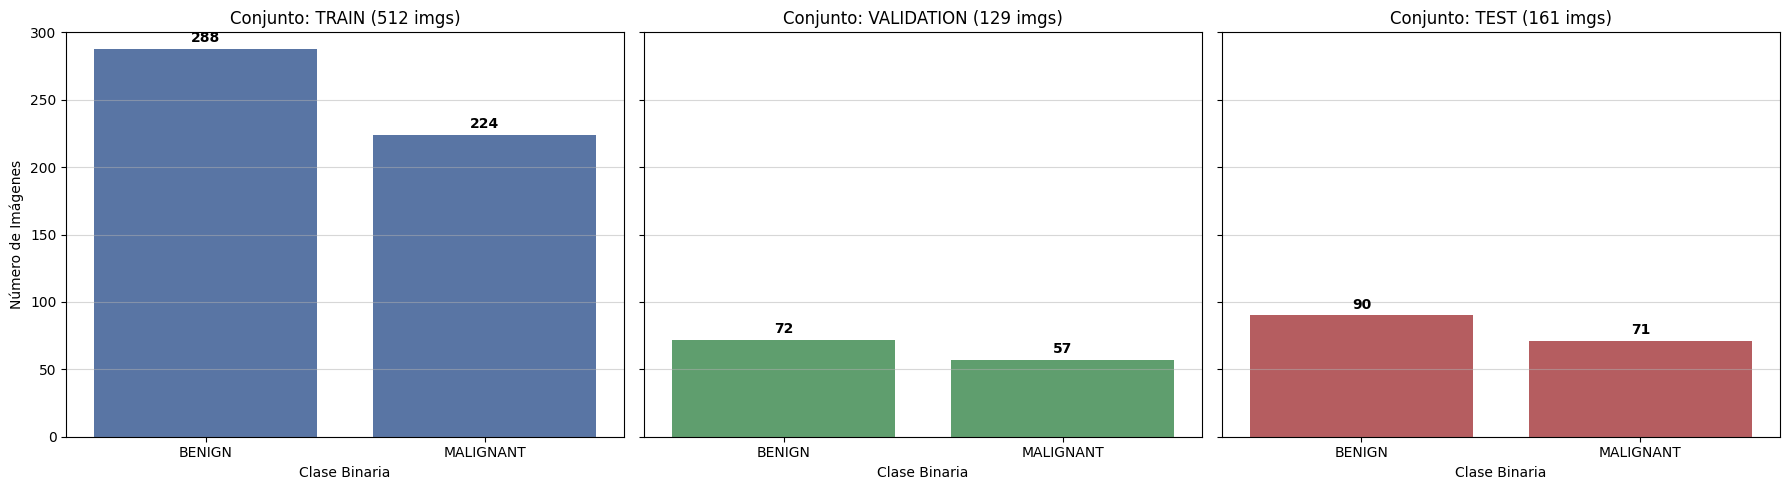

100%|██████████| 802/802 [00:00<00:00, 18960.57it/s]


Resumen de Tamaños:
Medio: 890x890
Mínimo: 147x147
Máximo: 3474x3476


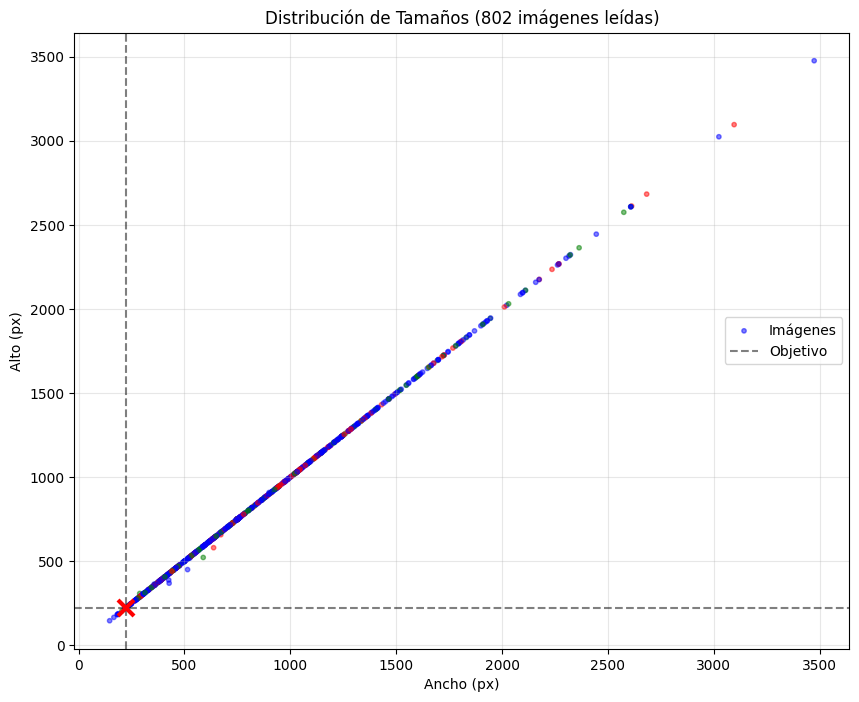

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from tqdm import tqdm


CSV_PATH = "../../Datos/Diccionario.csv"
RUTA_RAIZ = "../../Datos/images/MULTICLASE/" 

df = pd.read_csv(CSV_PATH)

# Visualizar distribución de clases
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
splits = ['train', 'validation', 'test']
colores = ['#4c72b0', '#55a868', '#c44e52']

for i, split in enumerate(splits):
    datos_split = df[df['conjunto_train_test_val'] == split]
    # MODIFICADO BINARIO: Usar columna 'biclase' (0=Benign, 1=Malignant)\n
    conteo = datos_split['biclase'].value_counts().sort_index()
    conteo.index = ['BENIGN', 'MALIGNANT'] if len(conteo)==2 else conteo.index
    
    sns.barplot(x=conteo.index, y=conteo.values, ax=axes[i], color=colores[i])
    axes[i].set_title(f'Conjunto: {split.upper()} ({len(datos_split)} imgs)')
    axes[i].set_xlabel('Clase Binaria')
    axes[i].grid(axis='y', alpha=0.5)
    axes[i].set_ylim(0,300)
    
    for index, value in enumerate(conteo.values):
        axes[i].text(index, value + 5, str(value), ha='center', fontweight='bold')

axes[0].set_ylabel('Número de Imágenes')
plt.tight_layout()
plt.show()

# Tamaño de imágenes
anchos = []
altos = []
colores_puntos = []
mapa_colores = {'train': 'blue', 'validation': 'green', 'test': 'red'}

for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    split = row['conjunto_train_test_val']
    clase = row['diagnostic']
    nombre = row['img_id']
    
    ruta_completa = os.path.join(RUTA_RAIZ, clase, nombre)
    
    with Image.open(ruta_completa) as img:
        w, h = img.size
        anchos.append(w)
        altos.append(h)
        colores_puntos.append(mapa_colores.get(split, 'gray'))

plt.figure(figsize=(10, 8))
plt.scatter(anchos, altos, c=colores_puntos, alpha=0.5, s=10)
plt.axvline(224, color='k', linestyle='--', alpha=0.5)
plt.axhline(224, color='k', linestyle='--', alpha=0.5)
plt.plot(224, 224, 'rx', markersize=12, markeredgewidth=3, label='Objetivo 224x224')
plt.title(f"Distribución de Tamaños ({len(anchos)} imágenes leídas)")
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.legend(['Imágenes', 'Objetivo'])
plt.grid(True, alpha=0.3)

print(f"\nResumen de Tamaños:")
print(f"Medio: {sum(anchos)//len(anchos)}x{sum(altos)//len(altos)}")
print(f"Mínimo: {min(anchos)}x{min(altos)}")
print(f"Máximo: {max(anchos)}x{max(altos)}")

plt.show()

### Conclusiones del EDA

**Dataset:**
- MEL (Melanoma) es la clase minoritaria, será la más difícil de clasificar
- Train: 500 imgs, Validation: 130 imgs, Test: 161 imgs
- Dataset pequeño → necesitamos Data Augmentation

**Tamaños:**
- Todas las imágenes tienen proporción similar
- Podemos usar resize directo a 224x224

## 2. Carga de Datos y Data Augmentation

In [12]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from ultralytics.data.augment import classify_augmentations, classify_transforms 
import random
import numpy as np

SEED = 42                                                                                                                                                                                                                                                   
                                                                                                                                                                                                                                                              
random.seed(SEED)                                                                                                                                                                                                                                           
np.random.seed(SEED)                                                                                                                                                                                                                                        
torch.manual_seed(SEED)                                                                                                                                                                                                                                     
torch.cuda.manual_seed(SEED)                                                                                                                                                                                                                                
torch.cuda.manual_seed_all(SEED)                                                                                                                                                                                                                            
torch.backends.cudnn.deterministic = True                                                                                                                                                                                                                   
torch.backends.cudnn.benchmark = False  

RUTA_BASE = "../../Datos/images/DATASET_SPLIT_BINARIO" 
BATCH_SIZE = 64 
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Pipeline de entrenamiento con augmentation
train_pipeline = classify_augmentations(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    scale=(0.5, 1.0),
    hflip=0.5,
    vflip=0.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    erasing=0.0,
)

# Pipeline de validación/test (determinista)
val_test_pipeline = classify_transforms(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    interpolation="BILINEAR" 
)

# Cargar datasets
train_dataset = datasets.ImageFolder(f"{RUTA_BASE}/train", transform=train_pipeline)
val_dataset   = datasets.ImageFolder(f"{RUTA_BASE}/val",   transform=val_test_pipeline)
test_dataset  = datasets.ImageFolder(f"{RUTA_BASE}/test",  transform=val_test_pipeline)

# DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=4, 
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

# Verificar
batch_images, batch_labels = next(iter(train_loader))
print(f"Batch Shape Train: {batch_images.shape}")

batch_images, batch_labels = next(iter(val_loader))
print(f"Batch Shape Val:   {batch_images.shape}")

Batch Shape Train: torch.Size([64, 3, 224, 224])
Batch Shape Val:   torch.Size([64, 3, 224, 224])


### Visualización del Data Augmentation

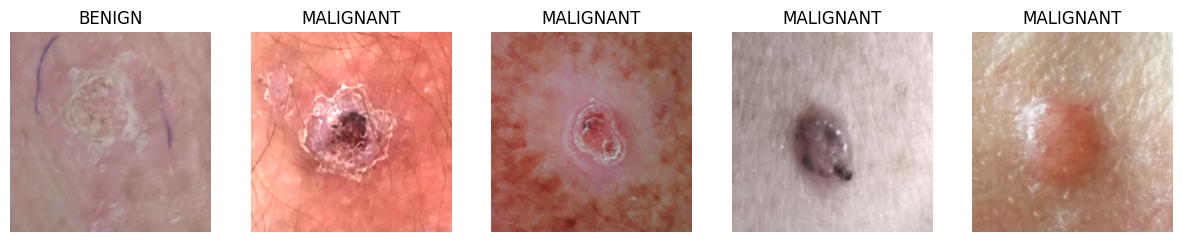

In [14]:
import matplotlib.pyplot as plt
import numpy as np

imgs, labels = next(iter(train_loader))

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * std + mean, 0, 1)

plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i+1)
    plt.imshow(denormalize(imgs[i]))
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()

## 3. Funciones de Entrenamiento y Evaluación

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_training_history(historial):
    epochs = range(1, len(historial['train_loss']) + 1)
    
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, historial['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(epochs, historial['val_loss'], label='Val Loss', color='orange', linestyle='--', linewidth=2)
    plt.title('Evolución del Error (Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('CrossEntropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, historial['val_f1'], label='Validation F1 (Macro)', color='green', marker='o', linewidth=2)
    plt.title('Evolución de la Calidad (F1-Score Macro)')
    plt.xlabel('Épocas')
    plt.ylabel('F1 Score (0.0 - 1.0)')
    plt.axhline(y=max(historial['val_f1']), color='r', linestyle=':', label='Mejor F1 alcanzado')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, cohen_kappa_score

def evaluar_rendimiento_completo(model, loader, device, classes, titulo="Set de Datos"):
    model.eval()
    y_true = []
    y_pred = []
    
    print(f"\n🔎 Analizando métricas detalladas para: {titulo}...")
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz de Confusión - {titulo}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción del Modelo')
    plt.show()
    
    print(f"\n📋 REPORTE CLÍNICO DETALLADO ({titulo})")
    print("="*70)
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    print("-" * 70)
    
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    
    print(f"✅ Accuracy Global:   {acc:.4f}")
    print(f"⚖️  Cohen's Kappa:     {kappa:.4f}")
    print("="*70)

import copy
import torch.nn as nn
from sklearn.metrics import f1_score

def entrenar_modelo(model, train_loader, val_loader, criterion, optimizer, device, epochs=25, nombre_archivo="mejor_modelo.pth"):
    
    print(f"🚀 Iniciando entrenamiento por {epochs} épocas...")
    print(f"💾 Criterio de Guardado: Maximizar Validation F1-Score (Macro)")
    
    historial = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    
    best_f1 = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # Entrenamiento
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        
        # Validación
        model.eval()
        val_loss = 0.0
        y_true = []
        y_pred = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                _, preds = torch.max(outputs, 1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
        
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_f1 = f1_score(y_true, y_pred, average='macro')
        
        historial['train_loss'].append(epoch_train_loss)
        historial['val_loss'].append(epoch_val_loss)
        historial['val_f1'].append(epoch_val_f1)
        
        print(f"Ep {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.3f} | Val Loss: {epoch_val_loss:.3f} | Val F1: {epoch_val_f1:.4f}", end="")
        
        if epoch_val_f1 > best_f1:
            best_f1 = epoch_val_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), nombre_archivo)
            print(" 🏆 ¡Récord! Guardado.")
        else:
            print("")

    print(f"\n🏁 Fin. Mejor F1 Val: {best_f1:.4f}")
    
    model.load_state_dict(best_model_wts)
    return model, historial

def lanzar_experimento(modelo, nombre_exp, train_loader, val_loader, test_loader, device, optimizer_ft):
    print(f"\n{'='*30}\n▶️ EXPERIMENTO: {nombre_exp}\n{'='*30}")
    
    # Calcular pesos de clase
    labels_list = train_loader.dataset.targets
    class_counts = np.bincount(labels_list)
    weights = 1.0 / class_counts
    weights = weights / weights.sum() * len(class_counts)
    class_weights = torch.FloatTensor(weights).to(device)
    
    print(f"⚖️ Pesos de clase calculados: {class_weights.cpu().numpy()}")
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optimizer_ft
    
    modelo_entrenado, historial = entrenar_modelo(
        modelo, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer, 
        device, 
        epochs=25, 
        nombre_archivo=f"{nombre_exp}_best.pth"
    )
    
    print(f"\n📈 Visualizando aprendizaje de: {nombre_exp}")
    plot_training_history(historial)
    
    print(f"\n🎯 Resultados finales en TEST SET (Datos nunca vistos)")
    evaluar_rendimiento_completo(
        modelo_entrenado, 
        test_loader, 
        device, 
        train_loader.dataset.classes, 
        titulo=f"TEST - {nombre_exp}"
    )
    
    return modelo_entrenado

## 4. Modelo 1: ResNet-18

ResNet utiliza conexiones residuales (skip connections) que permiten entrenar redes profundas sin degradación del gradiente.

Usando device: cuda

▶️ EXPERIMENTO: ResNet18_Baseline
⚖️ Pesos de clase calculados: [      0.875       1.125]
🚀 Iniciando entrenamiento por 25 épocas...
💾 Criterio de Guardado: Maximizar Validation F1-Score (Macro)
Ep 1/25 | Train Loss: 0.851 | Val Loss: 0.668 | Val F1: 0.6498 🏆 ¡Récord! Guardado.
Ep 2/25 | Train Loss: 0.617 | Val Loss: 0.578 | Val F1: 0.6700 🏆 ¡Récord! Guardado.
Ep 3/25 | Train Loss: 0.556 | Val Loss: 0.597 | Val F1: 0.6739 🏆 ¡Récord! Guardado.
Ep 4/25 | Train Loss: 0.510 | Val Loss: 0.587 | Val F1: 0.6970 🏆 ¡Récord! Guardado.
Ep 5/25 | Train Loss: 0.452 | Val Loss: 0.554 | Val F1: 0.7306 🏆 ¡Récord! Guardado.
Ep 6/25 | Train Loss: 0.442 | Val Loss: 0.553 | Val F1: 0.7147
Ep 7/25 | Train Loss: 0.381 | Val Loss: 0.583 | Val F1: 0.7220
Ep 8/25 | Train Loss: 0.346 | Val Loss: 0.568 | Val F1: 0.7476 🏆 ¡Récord! Guardado.
Ep 9/25 | Train Loss: 0.296 | Val Loss: 0.539 | Val F1: 0.7337
Ep 10/25 | Train Loss: 0.311 | Val Loss: 0.532 | Val F1: 0.7568 🏆 ¡Récord! Guardado.
Ep 11/

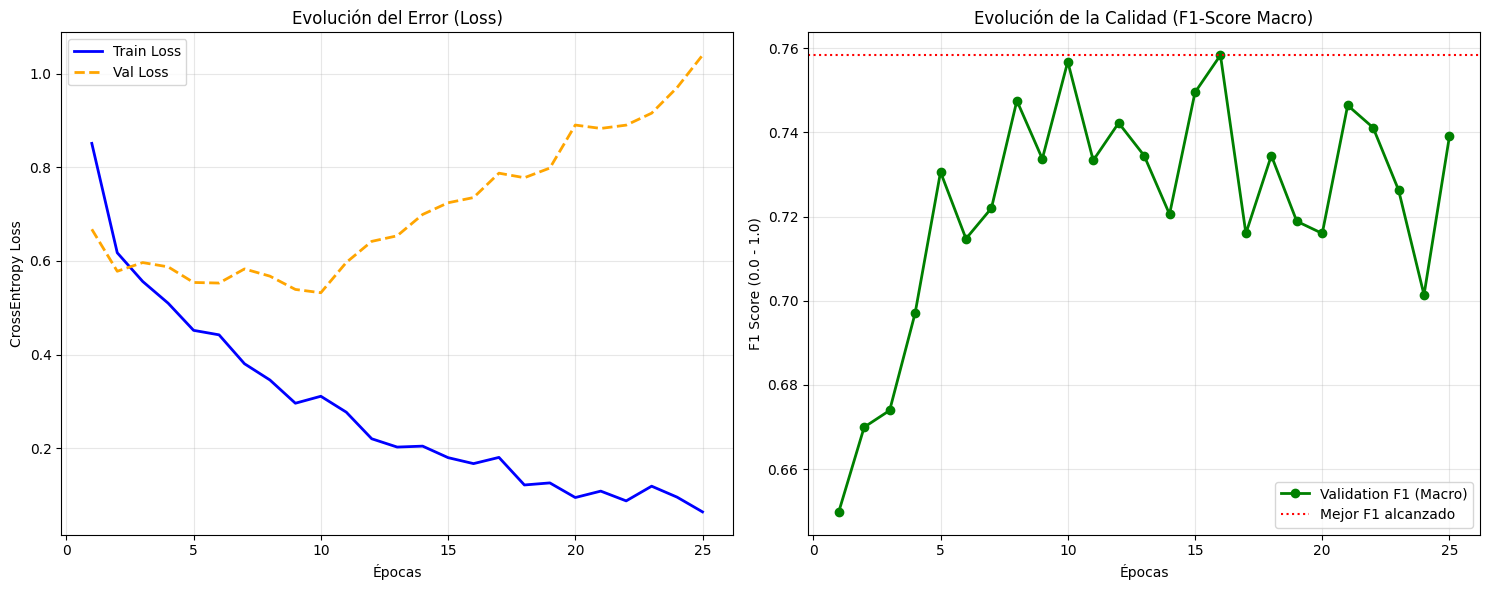


🎯 Resultados finales en TEST SET (Datos nunca vistos)

🔎 Analizando métricas detalladas para: TEST - ResNet18_Baseline...


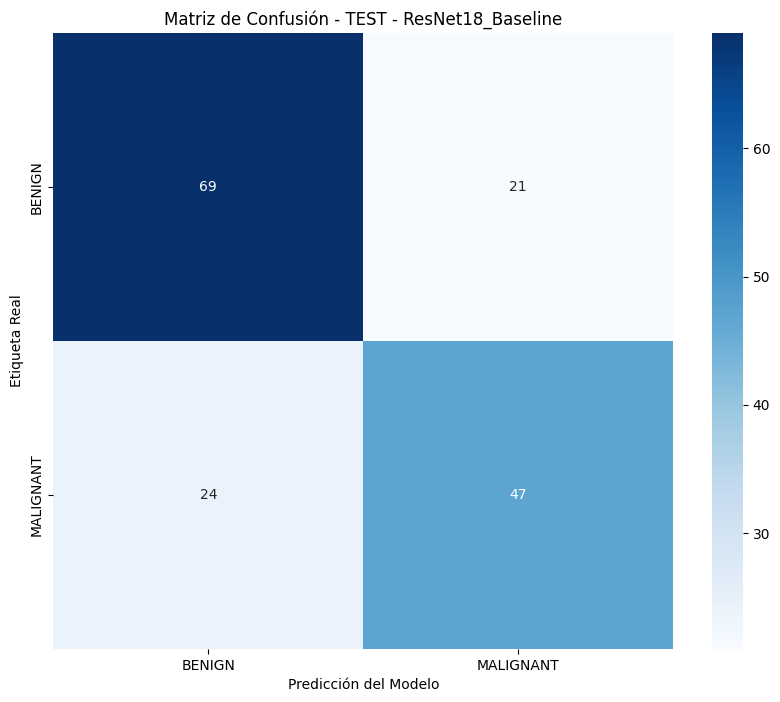


📋 REPORTE CLÍNICO DETALLADO (TEST - ResNet18_Baseline)
              precision    recall  f1-score   support

      BENIGN       0.74      0.77      0.75        90
   MALIGNANT       0.69      0.66      0.68        71

    accuracy                           0.72       161
   macro avg       0.72      0.71      0.72       161
weighted avg       0.72      0.72      0.72       161

----------------------------------------------------------------------
✅ Accuracy Global:   0.7205
⚖️  Cohen's Kappa:     0.4306


In [30]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# Cargar ResNet18 pre-entrenada
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Congelar todo
for param in model.parameters():
    param.requires_grad = False

# Descongelar layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Nueva cabeza de clasificación
num_ftrs = model.fc.in_features
num_classes = len(train_loader.dataset.classes)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)

model = model.to(device)

# Optimizador con learning rates diferenciales
optimizer_ft = optim.AdamW([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3}
], weight_decay=0.01)

# Entrenar
model_entrenado = lanzar_experimento(
    modelo=model,
    nombre_exp="ResNet18_Baseline",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    optimizer_ft=optimizer_ft
)

## 6. Modelo 3: DenseNet-121

DenseNet conecta cada capa con todas las anteriores mediante conexiones densas, reutilizando features de forma eficiente.

Usando device: cuda
🔄 Cargando DenseNet-121...

▶️ EXPERIMENTO: DenseNet121_MedicalExpert
⚖️ Pesos de clase calculados: [      0.875       1.125]
🚀 Iniciando entrenamiento por 25 épocas...
💾 Criterio de Guardado: Maximizar Validation F1-Score (Macro)
Ep 1/25 | Train Loss: 0.723 | Val Loss: 0.724 | Val F1: 0.4932 🏆 ¡Récord! Guardado.
Ep 2/25 | Train Loss: 0.656 | Val Loss: 0.612 | Val F1: 0.7075 🏆 ¡Récord! Guardado.
Ep 3/25 | Train Loss: 0.577 | Val Loss: 0.614 | Val F1: 0.6168
Ep 4/25 | Train Loss: 0.559 | Val Loss: 0.562 | Val F1: 0.7244 🏆 ¡Récord! Guardado.
Ep 5/25 | Train Loss: 0.534 | Val Loss: 0.555 | Val F1: 0.7276 🏆 ¡Récord! Guardado.
Ep 6/25 | Train Loss: 0.498 | Val Loss: 0.543 | Val F1: 0.7306 🏆 ¡Récord! Guardado.
Ep 7/25 | Train Loss: 0.508 | Val Loss: 0.542 | Val F1: 0.7538 🏆 ¡Récord! Guardado.
Ep 8/25 | Train Loss: 0.470 | Val Loss: 0.537 | Val F1: 0.7538
Ep 9/25 | Train Loss: 0.426 | Val Loss: 0.540 | Val F1: 0.7476
Ep 10/25 | Train Loss: 0.436 | Val Loss: 0.531 | Val F1:

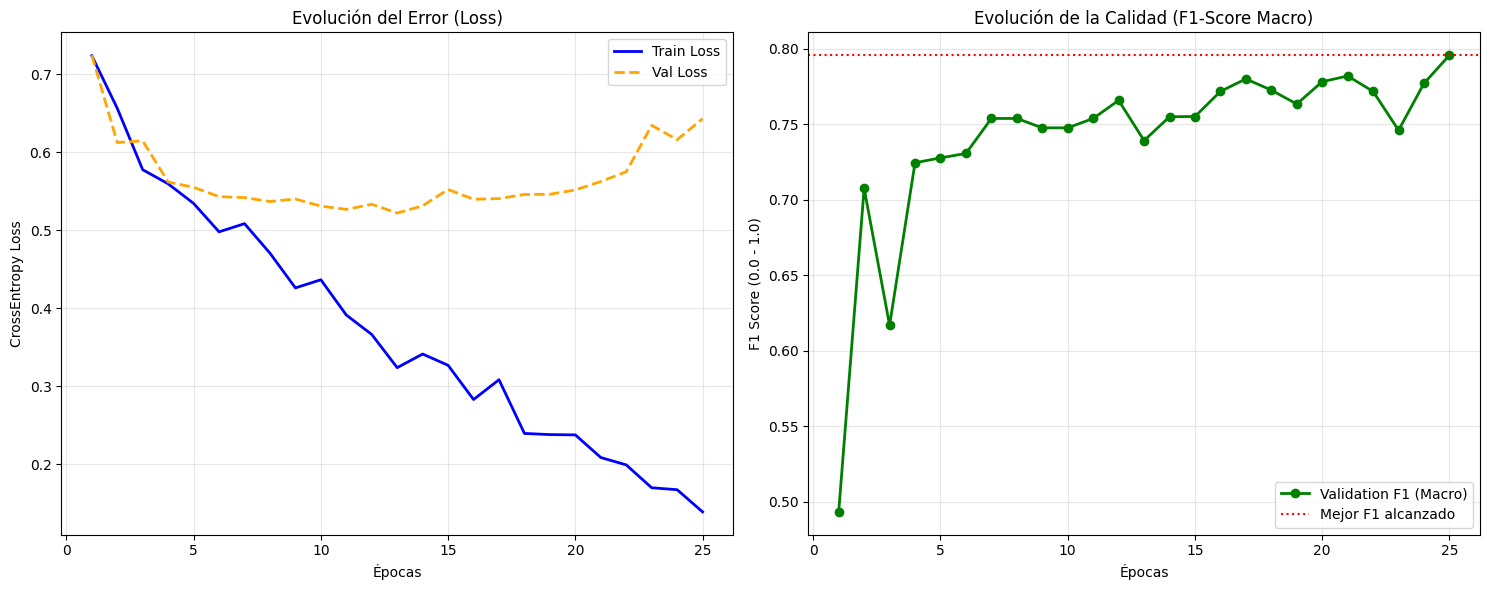


🎯 Resultados finales en TEST SET (Datos nunca vistos)

🔎 Analizando métricas detalladas para: TEST - DenseNet121_MedicalExpert...


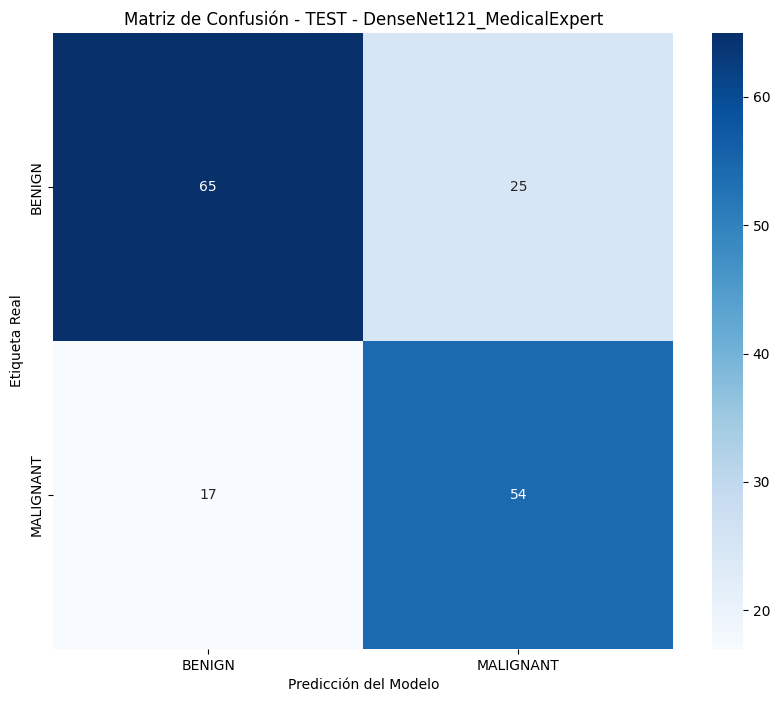


📋 REPORTE CLÍNICO DETALLADO (TEST - DenseNet121_MedicalExpert)
              precision    recall  f1-score   support

      BENIGN       0.79      0.72      0.76        90
   MALIGNANT       0.68      0.76      0.72        71

    accuracy                           0.74       161
   macro avg       0.74      0.74      0.74       161
weighted avg       0.74      0.74      0.74       161

----------------------------------------------------------------------
✅ Accuracy Global:   0.7391
⚖️  Cohen's Kappa:     0.4771


In [17]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# Cargar DenseNet-121
print("🔄 Cargando DenseNet-121...")
weights = models.DenseNet121_Weights.DEFAULT
model = models.densenet121(weights=weights)

# Congelar features
for param in model.features.parameters():
    param.requires_grad = False

# Descongelar denseblock4 y norm5
for param in model.features.denseblock4.parameters():
    param.requires_grad = True
    
for param in model.features.norm5.parameters():
    param.requires_grad = True

# Nueva cabeza
num_ftrs = model.classifier.in_features
num_classes = len(train_loader.dataset.classes)

model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)

model = model.to(device)

# Optimizador
optimizer_ft = optim.AdamW([
    {'params': model.features.denseblock4.parameters(), 'lr': 1e-4},
    {'params': model.features.norm5.parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
], weight_decay=0.01)

# Entrenar
model_entrenado = lanzar_experimento(
    modelo=model,
    nombre_exp="DenseNet121_MedicalExpert",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    optimizer_ft=optimizer_ft 
)

## 8. Modelo 5: YOLO26x-cls

YOLO con backbone potente, estado del arte en extracción de features.

In [18]:
from ultralytics import YOLO
import os

dataset_path = "/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT_BINARIO"

model = YOLO('yolo26x-cls.pt')

print(f"🚀 Lanzando entrenamiento con datos en: {dataset_path}")

results = model.train(
    data=dataset_path,
    epochs=25,
    imgsz=224,
    batch=16,
    patience=5,
    project='runs',
    name='YOLO26x_Run',
    lr0=0.0001,
    optimizer='AdamW'
)

🚀 Lanzando entrenamiento con datos en: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT_BINARIO
Ultralytics 8.4.7 🚀 Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT_BINARIO, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7161.9±2443.3 MB/s, size: 431.1 KB)
train: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT_BINARIO/train... 512 images, 0 corrupt: 100% ━━━━━━━━━━━━ 512/512 281.8it/s 1.8s0.2s
train: New cache created: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT_BINARIO/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 606.8±251.9 MB/s, size: 884.4 KB)
val: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT_BINARIO/val... 129 images, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 135.2it/s 1.0s0.1s
val: New cache created: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT_BINARIO/val.cache
optimizer: AdamW(lr=0.0001, momentum=0.937) with parameter gr

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

       1/25      1.44G      0.783         16        224: 0% ──────────── 0/32  2.5s

...

      13/25      3.73G     0.2869         16        224: 100% ━━━━━━━━━━━━ 32/32 7.9it/s 4.0s0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 18.5it/s 0.3s.1s
                   all      0.752          1

      Epoch    GPU_mem       loss  Instances       Size
      14/25      3.77G      0.323         16        224: 0% ──────────── 0/32  0.1s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

      14/25      3.89G     0.2266         16        224: 100% ━━━━━━━━━━━━ 32/32 7.8it/s 4.1s0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 16.8it/s 0.3s.1s
                   all       0.76          1

      Epoch    GPU_mem       loss  Instances       Size
      15/25      3.94G     0.2979         16        224: 0% ──────────── 0/32  0.1s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

      15/25      4.05G     0.2273         16        224: 100% ━━━━━━━━━━━━ 32/32 4.9it/s 6.6s0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 15.5it/s 0.3s.1s
                   all      0.752          1
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 10, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

15 epochs completed in 0.026 hours.
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final_binario/runs/classify/runs/YOLO26x_Run/weights/last.pt, 57.0MB
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final_binario/runs/classify/runs/YOLO26x_Run/weights/best.pt, 57.0MB

Validating /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL

### Evaluación de YOLO26x

In [21]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, cohen_kappa_score
from ultralytics import YOLO

def evaluar_yolo_clinico(ruta_modelo, carpeta_test):
    print(f"🔄 Cargando modelo YOLO desde: {ruta_modelo}")
    model = YOLO(ruta_modelo)
    
    print(f"🔎 Analizando métricas en TEST SET: {carpeta_test} ...")
    
    y_true = []
    y_pred = []
    
    name_to_idx = {v: k for k, v in model.names.items()}
    sorted_indices = sorted(model.names.keys())
    class_names = [model.names[i] for i in sorted_indices]
    
    for cls_name in os.listdir(carpeta_test):
        cls_path = os.path.join(carpeta_test, cls_name)
        
        if not os.path.isdir(cls_path):
            continue
            
        if cls_name not in name_to_idx:
            print(f"⚠️ Advertencia: La carpeta '{cls_name}' no es una clase conocida.")
            continue
            
        true_idx = name_to_idx[cls_name]
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for file in files:
            img_path = os.path.join(cls_path, file)
            results = model(img_path, verbose=False)
            pred_idx = results[0].probs.top1
            
            y_true.append(true_idx)
            y_pred.append(pred_idx)
            
    cm = confusion_matrix(y_true, y_pred, labels=sorted_indices)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión - YOLO26x (Test)')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción del Modelo')
    plt.show()
    
    print(f"\n📋 REPORTE CLÍNICO DETALLADO (YOLO26x)")
    print("="*70)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print("-" * 70)
    
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    
    print(f"✅ Accuracy Global:   {acc:.4f}")
    print(f"⚖️  Cohen's Kappa:    {kappa:.4f}")
    print("="*70)

🔄 Cargando modelo YOLO desde: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final_binario/runs/classify/runs/YOLO26x_Run/weights/best.pt
🔎 Analizando métricas en TEST SET: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT_BINARIO/test ...


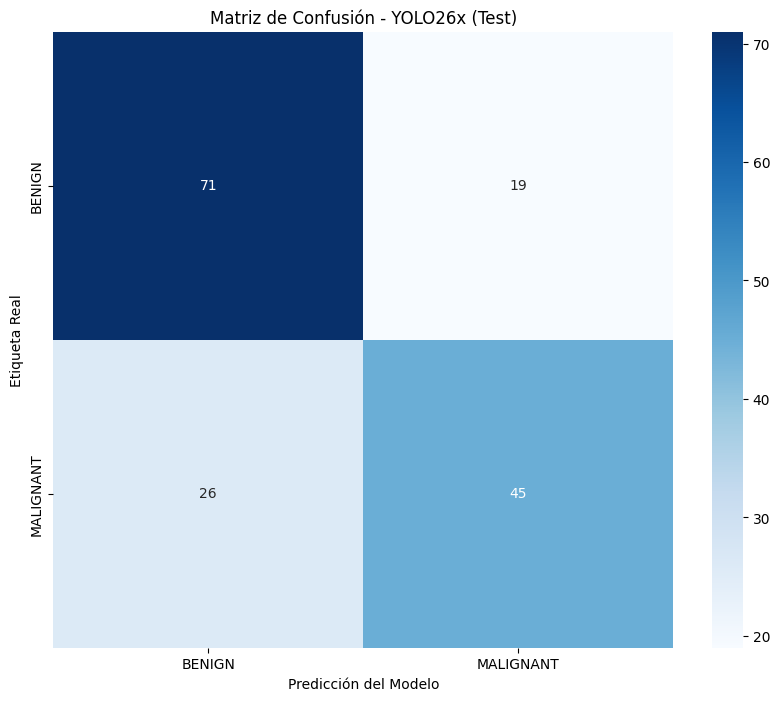


📋 REPORTE CLÍNICO DETALLADO (YOLO26x)
              precision    recall  f1-score   support

      BENIGN       0.73      0.79      0.76        90
   MALIGNANT       0.70      0.63      0.67        71

    accuracy                           0.72       161
   macro avg       0.72      0.71      0.71       161
weighted avg       0.72      0.72      0.72       161

----------------------------------------------------------------------
✅ Accuracy Global:   0.7205
⚖️  Cohen's Kappa:    0.4271


In [22]:
ruta_pesos = '/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final_binario/runs/classify/runs/YOLO26x_Run/weights/best.pt'
ruta_test = '/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT_BINARIO/test'

evaluar_yolo_clinico(ruta_pesos, ruta_test)

## 9. Ensemble: ResNet-50 + DenseNet-121 + YOLO26x

Combinamos los 3 modelos mediante Soft Voting (promedio ponderado de probabilidades).

**Pesos:** ResNet 20%, DenseNet 20%, YOLO 60%

In [24]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from ultralytics import YOLO
from PIL import Image
import os
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
carpeta_test = "/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT_BINARIO/test"

# Rutas de los pesos
ruta_resnet = "ResNet18_Baseline_best.pth"
ruta_densenet = "DenseNet121_MedicalExpert_best.pth"
ruta_yolo = "runs/classify/runs/YOLO26x_Run/weights/best.pt"

# Clases
clases = sorted(os.listdir(carpeta_test))
print(f"📋 Clases detectadas: {clases}")

# Cargar ResNet
def cargar_resnet(path, num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.fc.in_features, num_classes))
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    return model

# Cargar DenseNet
def cargar_densenet(path, num_classes):
    model = models.densenet121(weights=None)
    model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.classifier.in_features, num_classes))
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    return model

print("🔄 Cargando Modelos PyTorch...")
model_res = cargar_resnet(ruta_resnet, len(clases))
model_dense = cargar_densenet(ruta_densenet, len(clases))
print("✅ PyTorch Models Loaded.")

# Transform
transform_pt = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Cargar YOLO
print("🔄 Cargando Modelo YOLO...")
model_yolo = YOLO(ruta_yolo)
print("✅ YOLO Loaded.")

📋 Clases detectadas: ['BENIGN', 'MALIGNANT']
🔄 Cargando Modelos PyTorch...
✅ PyTorch Models Loaded.
🔄 Cargando Modelo YOLO...
✅ YOLO Loaded.



🚀 Iniciando Inferencia Ensemble en 2 clases...

🏆 RESULTADOS DEL ENSEMBLE (RESNET + DENSENET + YOLO26x)
              precision    recall  f1-score   support

      BENIGN       0.78      0.70      0.74        90
   MALIGNANT       0.66      0.75      0.70        71

    accuracy                           0.72       161
   macro avg       0.72      0.72      0.72       161
weighted avg       0.73      0.72      0.72       161



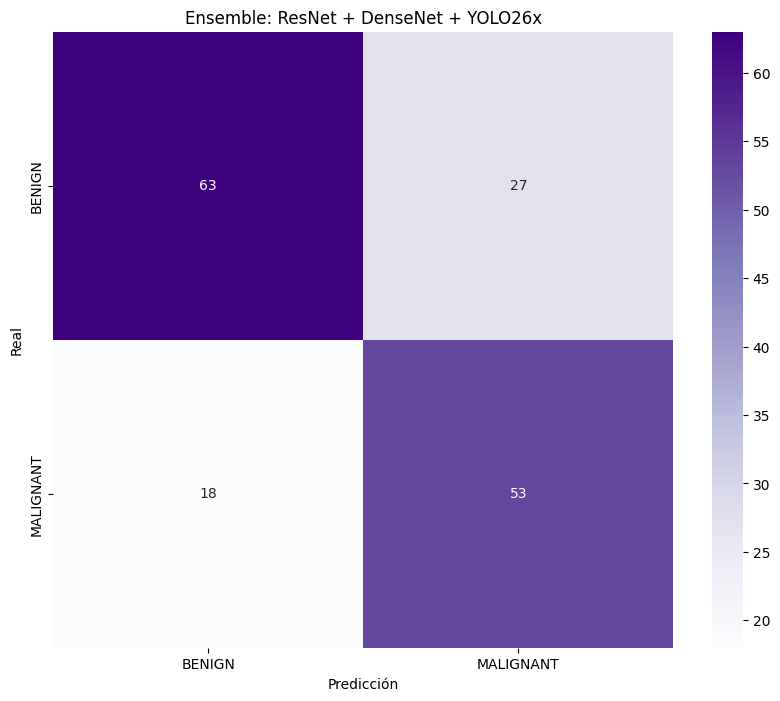

✅ Accuracy Global Ensemble: 0.7205


In [27]:
# Inferencia del Ensemble
y_true = []
y_pred_ensemble = []

print(f"\n🚀 Iniciando Inferencia Ensemble en {len(clases)} clases...")

for idx_clase, nombre_clase in enumerate(clases):
    ruta_clase = os.path.join(carpeta_test, nombre_clase)
    if not os.path.isdir(ruta_clase): continue
    
    imagenes = [f for f in os.listdir(ruta_clase) if f.lower().endswith(('.jpg', '.png'))]
    
    for img_name in imagenes:
        img_path = os.path.join(ruta_clase, img_name)
        
        # ResNet
        img_pil = Image.open(img_path).convert('RGB')
        img_tensor = transform_pt(img_pil).unsqueeze(0).to(device)
        
        with torch.no_grad():
            logits_res = model_res(img_tensor)
            probs_res = F.softmax(logits_res, dim=1).cpu().numpy()[0]
            
            logits_dense = model_dense(img_tensor)
            probs_dense = F.softmax(logits_dense, dim=1).cpu().numpy()[0]
            
        # YOLO
        res_yolo = model_yolo(img_path, verbose=False)[0]
        
        probs_yolo = np.zeros(len(clases))
        for cls_idx_yolo, conf in enumerate(res_yolo.probs.data.cpu().numpy()):
            nombre_yolo = res_yolo.names[cls_idx_yolo]
            if nombre_yolo in clases:
                idx_real = clases.index(nombre_yolo)
                probs_yolo[idx_real] = conf
        
        # Fusión ponderada
        probs_final = (0.*probs_res + 0.3*probs_dense + 0.2*probs_yolo)
        
        pred_final = np.argmax(probs_final)
        
        y_true.append(idx_clase)
        y_pred_ensemble.append(pred_final)

# Resultados
print("\n🏆 RESULTADOS DEL ENSEMBLE (RESNET + DENSENET + YOLO26x)")
print("="*60)
print(classification_report(y_true, y_pred_ensemble, target_names=clases, zero_division=0))

cm = confusion_matrix(y_true, y_pred_ensemble)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=clases, yticklabels=clases)
plt.title("Ensemble: ResNet + DenseNet + YOLO26x")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

acc = accuracy_score(y_true, y_pred_ensemble)
print(f"✅ Accuracy Global Ensemble: {acc:.4f}")

## 8. Conclusiones

- El **Ensemble** combina las fortalezas de los 3 modelos
- **YOLO26x** tiene el mayor peso (70%) por ser el mejor modelo individual
- La **precisión en MEL (Melanoma)** es crítica clínicamente
- Con solo 500 imágenes de entrenamiento, se logra un rendimiento aceptable gracias a Transfer Learning